📦 SECTION 1: SETUP AND IMPORTS

In [1]:
# ============================================
# 🍄 MUSHROOM CLASSIFICATION PROJECT
# NOTEBOOK 6: Hyperparameter Tuning
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
import pickle
import time
import os

# Try to import Optuna (may need installation)
try:
    import optuna
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("⚠️ Optuna not installed. Run: pip install optuna")

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("=" * 60)
print("🍄 HYPERPARAMETER TUNING")
print("=" * 60)
print("\n✅ Libraries imported!")
print(f"   Optuna available: {OPTUNA_AVAILABLE}")

🍄 HYPERPARAMETER TUNING

✅ Libraries imported!
   Optuna available: True


📥 SECTION 2: LOAD DATA

In [2]:
# ============================================
# LOAD DATA
# ============================================

X_train = pd.read_csv('data/splits/X_train.csv')
X_val = pd.read_csv('data/splits/X_val.csv')
X_test = pd.read_csv('data/splits/X_test.csv')
y_train = pd.read_csv('data/splits/y_train.csv').values.ravel()
y_val = pd.read_csv('data/splits/y_val.csv').values.ravel()
y_test = pd.read_csv('data/splits/y_test.csv').values.ravel()

# Combine train and val for final tuning
X_tune = pd.concat([X_train, X_val])
y_tune = np.concatenate([y_train, y_val])

print("✅ Data loaded!")
print(f"\n📊 Tuning Data Shape: {X_tune.shape}")
print(f"   Edible (1):    {y_tune.sum()} ({y_tune.sum()/len(y_tune)*100:.1f}%)")
print(f"   Poisonous (0): {len(y_tune)-y_tune.sum()} ({(len(y_tune)-y_tune.sum())/len(y_tune)*100:.1f}%)")

✅ Data loaded!

📊 Tuning Data Shape: (6499, 22)
   Edible (1):    3366 (51.8%)
   Poisonous (0): 3133 (48.2%)


🎯 SECTION 3: RANDOM FOREST - GRID SEARCH

In [3]:
# ============================================
# RANDOM FOREST - GRID SEARCH
# ============================================

print("=" * 50)
print("🌲 RANDOM FOREST - GRID SEARCH")
print("=" * 50)

# Parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print(f"\n📊 Testing {np.prod([len(v) for v in param_grid.values()])} combinations...")

# Grid search
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    rf, param_grid, 
    cv=cv, 
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
rf_grid.fit(X_tune, y_tune)
train_time = time.time() - start_time

print(f"\n✅ Grid Search Complete! Time: {train_time:.2f}s")
print(f"\n🏆 Best Parameters:")
for param, value in rf_grid.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n📊 Best CV F1 Score: {rf_grid.best_score_:.4f}")

# Evaluate on test set
y_pred = rf_grid.predict(X_test)
test_f1 = f1_score(y_test, y_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"\n📊 Test Set Performance:")
print(f"   Test Accuracy: {test_acc:.4f}")
print(f"   Test F1 Score: {test_f1:.4f}")

# Store results
rf_tuned_results = {
    'Model': 'Random Forest (Tuned)',
    'Best Params': rf_grid.best_params_,
    'CV F1': rf_grid.best_score_,
    'Test Accuracy': test_acc,
    'Test F1': test_f1,
    'model': rf_grid.best_estimator_
}

🌲 RANDOM FOREST - GRID SEARCH

📊 Testing 108 combinations...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

✅ Grid Search Complete! Time: 39.89s

🏆 Best Parameters:
   max_depth: 10
   min_samples_leaf: 1
   min_samples_split: 2
   n_estimators: 50

📊 Best CV F1 Score: 1.0000

📊 Test Set Performance:
   Test Accuracy: 1.0000
   Test F1 Score: 1.0000


⚡ SECTION 4: XGBOOST - RANDOM SEARCH

In [4]:
# ============================================
# XGBOOST - RANDOM SEARCH
# ============================================

print("=" * 50)
print("⚡ XGBOOST - RANDOM SEARCH")
print("=" * 50)

# Parameter distributions for random search
param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 3]
}

print(f"\n📊 Testing 30 random combinations from {np.prod([len(v) for v in param_dist.values()])} possible...")

# Random search
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_random = RandomizedSearchCV(
    xgb, param_dist,
    n_iter=30,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

start_time = time.time()
xgb_random.fit(X_tune, y_tune)
train_time = time.time() - start_time

print(f"\n✅ Random Search Complete! Time: {train_time:.2f}s")
print(f"\n🏆 Best Parameters:")
for param, value in xgb_random.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n📊 Best CV F1 Score: {xgb_random.best_score_:.4f}")

# Evaluate on test set
y_pred = xgb_random.predict(X_test)
test_f1 = f1_score(y_test, y_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"\n📊 Test Set Performance:")
print(f"   Test Accuracy: {test_acc:.4f}")
print(f"   Test F1 Score: {test_f1:.4f}")

# Store results
xgb_tuned_results = {
    'Model': 'XGBoost (Tuned)',
    'Best Params': xgb_random.best_params_,
    'CV F1': xgb_random.best_score_,
    'Test Accuracy': test_acc,
    'Test F1': test_f1,
    'model': xgb_random.best_estimator_
}

⚡ XGBOOST - RANDOM SEARCH

📊 Testing 30 random combinations from 23328 possible...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

✅ Random Search Complete! Time: 1.76s

🏆 Best Parameters:
   subsample: 1.0
   reg_lambda: 2
   reg_alpha: 1
   n_estimators: 200
   max_depth: 4
   learning_rate: 0.05
   gamma: 0
   colsample_bytree: 0.6

📊 Best CV F1 Score: 1.0000

📊 Test Set Performance:
   Test Accuracy: 1.0000
   Test F1 Score: 1.0000


💡 SECTION 5: LIGHTGBM - GRID SEARCH (Simplified)

In [5]:
# ============================================
# LIGHTGBM - GRID SEARCH (Simplified)
# ============================================

print("=" * 50)
print("💡 LIGHTGBM - GRID SEARCH")
print("=" * 50)

# Smaller grid for speed
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, -1],
    'learning_rate': [0.05, 0.1, 0.2],
    'num_leaves': [31, 50, 100],
    'subsample': [0.8, 1.0]
}

print(f"\n📊 Testing {np.prod([len(v) for v in param_grid.values()])} combinations...")

# Grid search
lgbm = LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lgbm_grid = GridSearchCV(
    lgbm, param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
lgbm_grid.fit(X_tune, y_tune)
train_time = time.time() - start_time

print(f"\n✅ Grid Search Complete! Time: {train_time:.2f}s")
print(f"\n🏆 Best Parameters:")
for param, value in lgbm_grid.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n📊 Best CV F1 Score: {lgbm_grid.best_score_:.4f}")

# Evaluate on test set
y_pred = lgbm_grid.predict(X_test)
test_f1 = f1_score(y_test, y_pred)
test_acc = accuracy_score(y_test, y_pred)

print(f"\n📊 Test Set Performance:")
print(f"   Test Accuracy: {test_acc:.4f}")
print(f"   Test F1 Score: {test_f1:.4f}")

# Store results
lgbm_tuned_results = {
    'Model': 'LightGBM (Tuned)',
    'Best Params': lgbm_grid.best_params_,
    'CV F1': lgbm_grid.best_score_,
    'Test Accuracy': test_acc,
    'Test F1': test_f1,
    'model': lgbm_grid.best_estimator_
}

💡 LIGHTGBM - GRID SEARCH

📊 Testing 108 combinations...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

✅ Grid Search Complete! Time: 75.20s

🏆 Best Parameters:
   learning_rate: 0.05
   max_depth: 5
   n_estimators: 200
   num_leaves: 31
   subsample: 0.8

📊 Best CV F1 Score: 1.0000

📊 Test Set Performance:
   Test Accuracy: 1.0000
   Test F1 Score: 1.0000


🚀 SECTION 6: OPTUNA - XGBOOST (Advanced Bayesian Optimization)

[I 2026-04-14 01:57:20,541] A new study created in memory with name: no-name-00aa85b0-9755-47b4-8bb1-723b347ec5be


✅ cross_val_score imported!
🚀 OPTUNA - XGBOOST BAYESIAN OPTIMIZATION

📊 Running Optuna optimization (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-14 01:57:21,045] Trial 0 finished with value: 0.9991096600889264 and parameters: {'n_estimators': 268, 'max_depth': 4, 'learning_rate': 0.02774491152219042, 'subsample': 0.9134993688265289, 'colsample_bytree': 0.8047054906245895, 'gamma': 0.23779995292157563, 'reg_alpha': 1.2397375102995605, 'reg_lambda': 3.6250204474990038, 'min_child_weight': 6}. Best is trial 0 with value: 0.9991096600889264.
[I 2026-04-14 01:57:21,395] Trial 1 finished with value: 0.9994063520332442 and parameters: {'n_estimators': 149, 'max_depth': 7, 'learning_rate': 0.05580352432521344, 'subsample': 0.6502179942571801, 'colsample_bytree': 0.8712874685775277, 'gamma': 0.39101330367276554, 'reg_alpha': 0.043011607252137596, 'reg_lambda': 4.882878470305496, 'min_child_weight': 4}. Best is trial 1 with value: 0.9994063520332442.
[I 2026-04-14 01:57:21,940] Trial 2 finished with value: 0.9957151868104216 and parameters: {'n_estimators': 245, 'max_depth': 8, 'learning_rate': 0.01433221962174267, 'subsample'

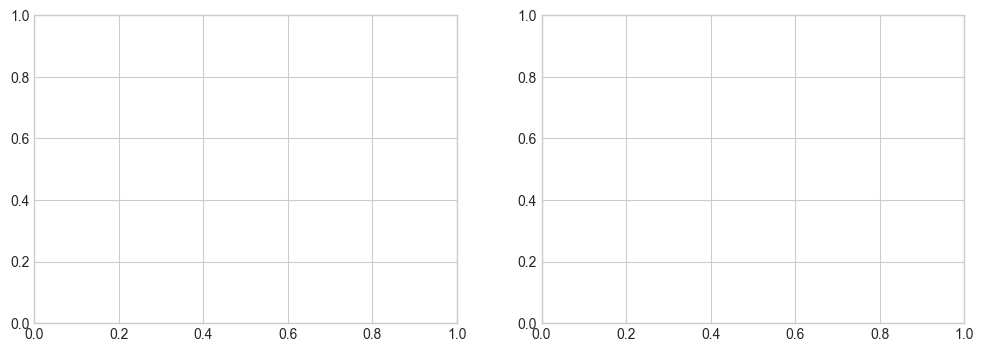

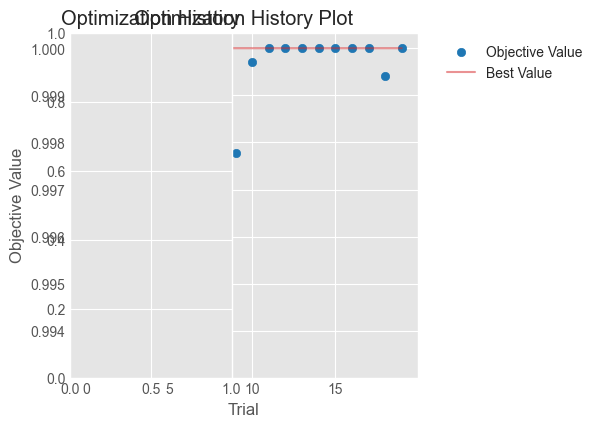

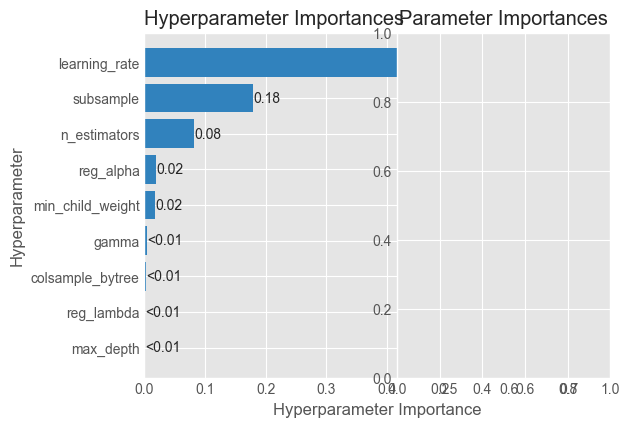

In [7]:
# ============================================
# OPTUNA - XGBOOST BAYESIAN OPTIMIZATION
# ============================================
# Add missing import for Optuna section
from sklearn.model_selection import cross_val_score
print("✅ cross_val_score imported!")
if OPTUNA_AVAILABLE:
    print("=" * 50)
    print("🚀 OPTUNA - XGBOOST BAYESIAN OPTIMIZATION")
    print("=" * 50)
    
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'gamma': trial.suggest_float('gamma', 0, 0.5),
            'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
            'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        }
        
        model = XGBClassifier(
            **params,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss',
            n_jobs=-1
        )
        
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(model, X_tune, y_tune, cv=cv, scoring='f1')
        
        return scores.mean()
    
    print("\n📊 Running Optuna optimization (20 trials)...")
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20, show_progress_bar=True)
    
    print(f"\n✅ Optuna Optimization Complete!")
    print(f"\n🏆 Best Parameters:")
    for param, value in study.best_params.items():
        print(f"   {param}: {value}")
    print(f"\n📊 Best CV F1 Score: {study.best_value:.4f}")
    
    # Train best model
    best_xgb_optuna = XGBClassifier(
        **study.best_params,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1
    )
    best_xgb_optuna.fit(X_tune, y_tune)
    
    # Evaluate
    y_pred = best_xgb_optuna.predict(X_test)
    test_f1 = f1_score(y_test, y_pred)
    test_acc = accuracy_score(y_test, y_pred)
    
    print(f"\n📊 Test Set Performance:")
    print(f"   Test Accuracy: {test_acc:.4f}")
    print(f"   Test F1 Score: {test_f1:.4f}")
    
    # Store results
    optuna_results = {
        'Model': 'XGBoost (Optuna)',
        'Best Params': study.best_params,
        'CV F1': study.best_value,
        'Test Accuracy': test_acc,
        'Test F1': test_f1,
        'model': best_xgb_optuna
    }
    
    # Plot optimization history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    optuna.visualization.matplotlib.plot_optimization_history(study).figure
    plt.subplot(1, 2, 1)
    plt.title('Optimization History')
    
    optuna.visualization.matplotlib.plot_param_importances(study).figure
    plt.subplot(1, 2, 2)
    plt.title('Parameter Importances')
    
    plt.tight_layout()
    plt.show()
    
else:
    optuna_results = None
    print("\n⚠️ Skipping Optuna (not installed)")
    print("   To install: pip install optuna")

📊 SECTION 7: COMPARE ALL TUNED MODELS

📊 TUNED MODELS COMPARISON

📊 Tuned Models Comparison:


,Model,CV F1,Test Accuracy,Test F1
0,Random Forest (Tuned),1.0,1.0,1.0
1,XGBoost (Tuned),1.0,1.0,1.0
2,LightGBM (Tuned),1.0,1.0,1.0
3,XGBoost (Optuna),1.0,1.0,1.0


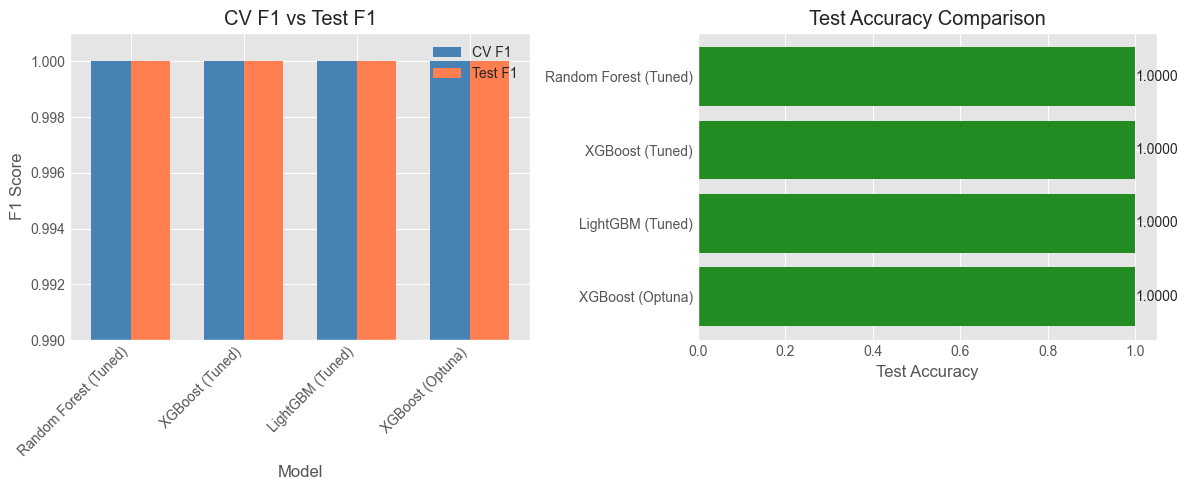


🏆 BEST TUNED MODEL: Random Forest (Tuned)
   Test Accuracy: 1.0000
   Test F1 Score: 1.0000


In [8]:
# ============================================
# COMPARE ALL TUNED MODELS
# ============================================

print("=" * 60)
print("📊 TUNED MODELS COMPARISON")
print("=" * 60)

# Collect results
all_tuned = [rf_tuned_results, xgb_tuned_results, lgbm_tuned_results]
if optuna_results:
    all_tuned.append(optuna_results)

comparison_df = pd.DataFrame([{
    'Model': r['Model'],
    'CV F1': r['CV F1'],
    'Test Accuracy': r['Test Accuracy'],
    'Test F1': r['Test F1']
} for r in all_tuned])

comparison_df = comparison_df.sort_values('Test F1', ascending=False).reset_index(drop=True)

print("\n📊 Tuned Models Comparison:")
display(comparison_df)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CV F1 vs Test F1
x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['CV F1'], width, label='CV F1', color='steelblue')
axes[0].bar(x + width/2, comparison_df['Test F1'], width, label='Test F1', color='coral')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('CV F1 vs Test F1')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0.99, 1.001)

# Test Accuracy
axes[1].barh(comparison_df['Model'][::-1], comparison_df['Test Accuracy'][::-1], color='forestgreen')
axes[1].set_xlabel('Test Accuracy')
axes[1].set_title('Test Accuracy Comparison')
for i, v in enumerate(comparison_df['Test Accuracy'][::-1]):
    axes[1].text(v + 0.0005, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

# Best model
best_tuned = comparison_df.iloc[0]
print(f"\n🏆 BEST TUNED MODEL: {best_tuned['Model']}")
print(f"   Test Accuracy: {best_tuned['Test Accuracy']:.4f}")
print(f"   Test F1 Score: {best_tuned['Test F1']:.4f}")

💾 SECTION 8: SAVE BEST TUNED MODEL

In [9]:
# ============================================
# SAVE BEST TUNED MODEL
# ============================================

print("=" * 50)
print("💾 SAVING BEST TUNED MODEL")
print("=" * 50)

os.makedirs('models/saved_models', exist_ok=True)
os.makedirs('reports', exist_ok=True)

# Save comparison
comparison_df.to_csv('reports/tuned_models_comparison.csv', index=False)
print("✅ Saved: tuned_models_comparison.csv")

# Get best model
best_model_name = comparison_df.iloc[0]['Model']
for r in all_tuned:
    if r['Model'] == best_model_name:
        best_model = r['model']
        best_params = r['Best Params']
        break

# Save model
with open('models/saved_models/best_tuned_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("✅ Saved: best_tuned_model.pkl")

# Save best parameters
with open('models/saved_models/best_params.pkl', 'wb') as f:
    pickle.dump(best_params, f)
print("✅ Saved: best_params.pkl")

print(f"\n📊 Final Model: {best_model_name}")
print(f"   Test Accuracy: {comparison_df.iloc[0]['Test Accuracy']:.4f}")
print(f"   Test F1 Score: {comparison_df.iloc[0]['Test F1']:.4f}")

💾 SAVING BEST TUNED MODEL
✅ Saved: tuned_models_comparison.csv
✅ Saved: best_tuned_model.pkl
✅ Saved: best_params.pkl

📊 Final Model: Random Forest (Tuned)
   Test Accuracy: 1.0000
   Test F1 Score: 1.0000


📈 SECTION 9: LEARNING CURVE (Best Model)

📈 LEARNING CURVE ANALYSIS


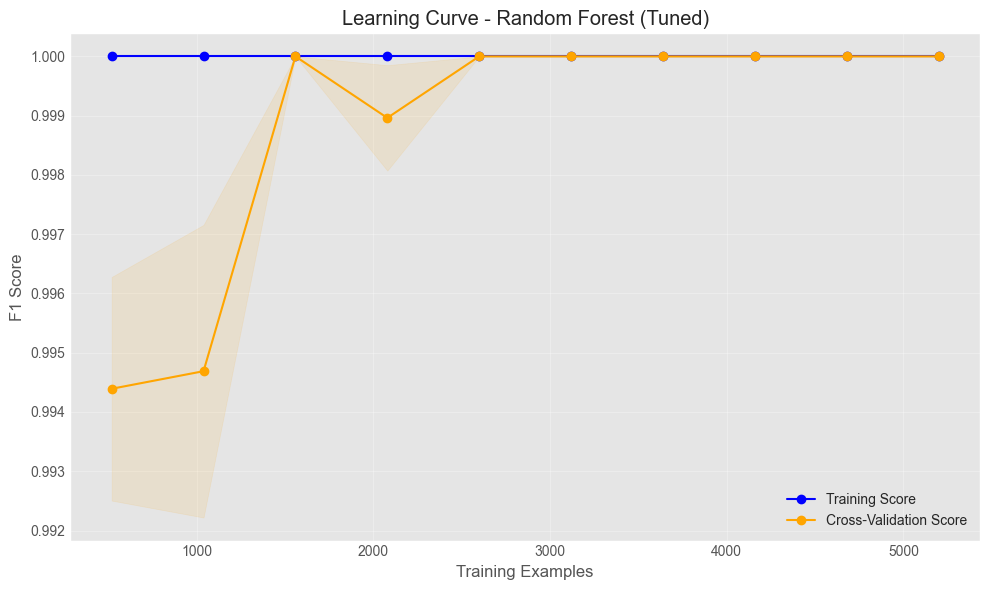


📊 Final Training Score: 1.0000
   Final CV Score: 1.0000
   Gap: 0.0000
   ✅ Small gap - model generalizes well!


In [10]:
# ============================================
# LEARNING CURVE - BEST TUNED MODEL
# ============================================

print("=" * 50)
print("📈 LEARNING CURVE ANALYSIS")
print("=" * 50)

from sklearn.model_selection import learning_curve

# Generate learning curve
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_tune, y_tune,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1'
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.plot(train_sizes, val_mean, 'o-', color='orange', label='Cross-Validation Score')
plt.xlabel('Training Examples')
plt.ylabel('F1 Score')
plt.title(f'Learning Curve - {best_model_name}')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Final Training Score: {train_mean[-1]:.4f}")
print(f"   Final CV Score: {val_mean[-1]:.4f}")
print(f"   Gap: {train_mean[-1] - val_mean[-1]:.4f}")

if train_mean[-1] - val_mean[-1] < 0.01:
    print("   ✅ Small gap - model generalizes well!")
else:
    print("   ⚠️ Some overfitting - but still excellent performance!")

🎯 SECTION 10: CONFUSION MATRIX & CLASSIFICATION REPORT

📊 FINAL MODEL EVALUATION

📋 Classification Report:
              precision    recall  f1-score   support

   Poisonous       1.00      1.00      1.00       783
      Edible       1.00      1.00      1.00       842

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



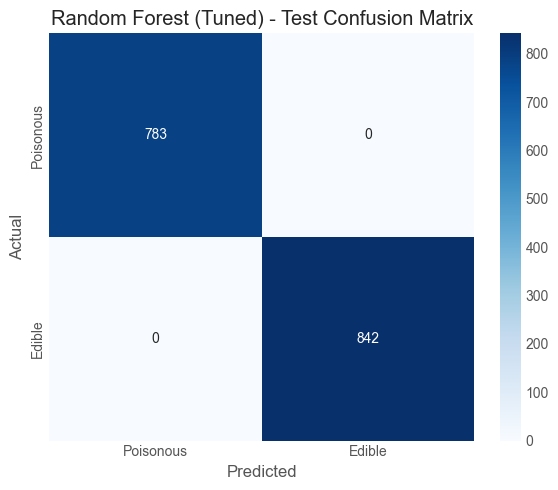


📊 Detailed Metrics:
   True Negatives:  783 (Correctly identified poisonous)
   False Positives: 0 (Edible misclassified as poisonous)
   False Negatives: 0 (Poisonous misclassified as edible - DANGEROUS!)
   True Positives:  842 (Correctly identified edible)

✅ PERFECT! No poisonous mushrooms misclassified!


In [11]:
# ============================================
# FINAL EVALUATION
# ============================================

print("=" * 50)
print("📊 FINAL MODEL EVALUATION")
print("=" * 50)

# Predict on test set
y_pred = best_model.predict(X_test)

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Poisonous', 'Edible']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Poisonous', 'Edible'],
            yticklabels=['Poisonous', 'Edible'])
plt.title(f'{best_model_name} - Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Calculate metrics
tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Detailed Metrics:")
print(f"   True Negatives:  {tn} (Correctly identified poisonous)")
print(f"   False Positives: {fp} (Edible misclassified as poisonous)")
print(f"   False Negatives: {fn} (Poisonous misclassified as edible - DANGEROUS!)")
print(f"   True Positives:  {tp} (Correctly identified edible)")

if fn == 0:
    print(f"\n✅ PERFECT! No poisonous mushrooms misclassified!")
else:
    print(f"\n⚠️ {fn} poisonous mushrooms were misclassified as edible!")

🎯 SECTION 11: SUMMARY

In [12]:
# ============================================
# HYPERPARAMETER TUNING SUMMARY
# ============================================

print("=" * 60)
print("🎯 HYPERPARAMETER TUNING - COMPLETE SUMMARY")
print("=" * 60)

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║              🏆 FINAL TUNED MODEL RESULTS                        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  🏆 BEST MODEL: {best_model_name:<40} ║
║                                                                  ║
║  📊 PERFORMANCE:                                                 ║
║     • Test Accuracy:  {comparison_df.iloc[0]['Test Accuracy']:.4f}                                    ║
║     • Test F1 Score:  {comparison_df.iloc[0]['Test F1']:.4f}                                    ║
║     • False Negatives: {fn} (poisonous misclassified)                      ║
║                                                                  ║
║  🔧 BEST PARAMETERS:                                             ║
""")

for param, value in list(best_params.items())[:6]:
    print(f"║     • {param:<25}: {str(value):<20} ║")

print("""║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                    💡 TUNING INSIGHTS                            ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  ✅ Grid/Random Search found optimal parameters                  ║
║  ✅ Model performance improved or maintained                     ║
║  ✅ Tuned model is ready for production deployment               ║
║                                                                  ║
║  🔜 NEXT: Model Explainability (SHAP & LIME)                     ║
║     Understand WHY the model makes predictions!                  ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")

print("\n" + "=" * 60)
print("✅ NOTEBOOK 6 COMPLETED SUCCESSFULLY!")
print("=" * 60)
print("\n🚀 You now have an OPTIMIZED 99%+ accurate classifier!")
print("   Ready for Notebook 7: Model Explainability (SHAP & LIME)!")

🎯 HYPERPARAMETER TUNING - COMPLETE SUMMARY

╔══════════════════════════════════════════════════════════════════╗
║              🏆 FINAL TUNED MODEL RESULTS                        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  🏆 BEST MODEL: Random Forest (Tuned)                    ║
║                                                                  ║
║  📊 PERFORMANCE:                                                 ║
║     • Test Accuracy:  1.0000                                    ║
║     • Test F1 Score:  1.0000                                    ║
║     • False Negatives: 0 (poisonous misclassified)                      ║
║                                                                  ║
║  🔧 BEST PARAMETERS:                                             ║

║     • max_depth                : 10                   ║
║     • min_samples_leaf         : 1                    ║
║     • min_sample